# 07. Train 내부 모델·UID 추가 검증
실험 실행: `python -m frauddetectionreport.model_validation`
4개 시간 fold × 가중치 유무 × UID 유무, 고정 300회. Raw AP 평균이 선택 기준이다.
기존 test 확인 후의 후속 진단이며, 기존 배포 예측을 자동 교체하지 않는다.


,fold,model,rounds,n_train,n_valid,train_max,valid_min,valid_max,p4_cost,pr_auc,roc_auc,k,precision_at_k,recall_at_k,ece,brier
0,0,plain_no_uid,300,76771,76770,1691336,1691374,3180379,183118.062312,0.570126,0.905263,500,0.950,0.233072,0.011475,0.016820
1,0,plain_uid,300,76771,76770,1691336,1691374,3180379,184804.913198,0.563116,0.903846,500,0.954,0.234053,0.011529,0.016913
2,0,weighted_no_uid,300,76771,76770,1691336,1691374,3180379,177971.189776,0.547226,0.896954,500,0.928,0.227674,0.007931,0.016966
3,0,weighted_uid,300,76771,76770,1691336,1691374,3180379,177677.889418,0.536986,0.894405,500,0.922,0.226202,0.008146,0.017194
4,1,plain_no_uid,300,153541,76770,3180379,3180380,5450309,255468.117062,0.612708,0.912658,500,0.986,0.155178,0.013276,0.024666
5,1,plain_uid,300,153541,76770,3180379,3180380,5450309,255738.851002,0.617343,0.912418,500,0.994,0.156437,0.015739,0.024816
6,1,weighted_no_uid,300,153541,76770,3180379,3180380,5450309,359158.642178,0.591068,0.904761,500,0.988,0.155493,0.037584,0.029408
7,1,weighted_uid,300,153541,76770,3180379,3180380,5450309,312104.860431,0.597169,0.908171,500,0.984,0.154863,0.027773,0.027086
8,2,plain_no_uid,300,230311,76771,5450309,5450316,7620476,227325.880743,0.660766,0.919479,500,0.994,0.158989,0.004433,0.021133
9,2,plain_uid,300,230311,76771,5450309,5450316,7620476,238665.219477,0.652490,0.922701,500,0.988,0.158029,0.005671,0.021560


,pr_auc,roc_auc,brier,ece,p4_cost
model,,,,,
plain_no_uid,0.601050,0.909832,0.021172,0.008915,231127.724408
plain_uid,0.599438,0.911406,0.021345,0.010063,233159.233798
weighted_no_uid,0.575028,0.903493,0.030773,0.050380,368175.007881
weighted_uid,0.574918,0.905196,0.029798,0.045679,348243.200401


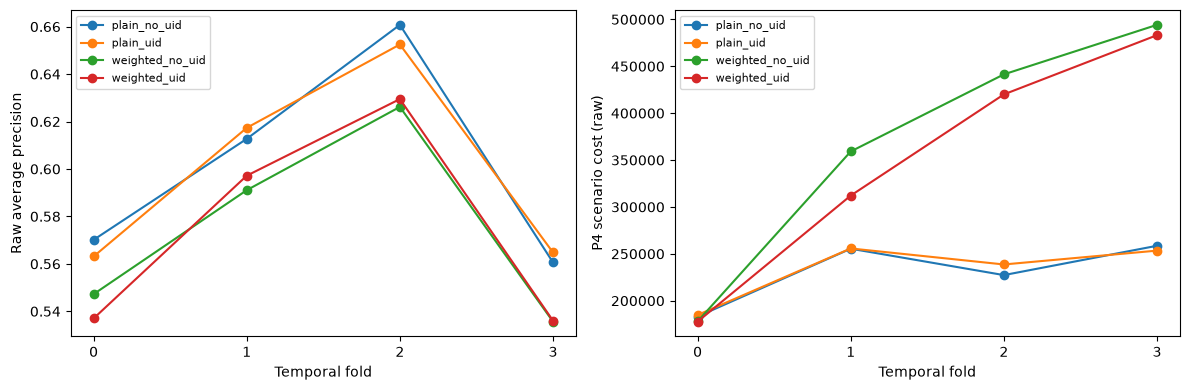

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
folder = ROOT / 'reports' / 'model_validation'
metrics = pd.read_csv(folder / 'fold_metrics.csv')
assert len(metrics) == 16, '16개 학습이 모두 끝난 후 실행하세요.'
display(metrics)
summary = metrics.groupby('model')[['pr_auc', 'roc_auc', 'brier', 'ece', 'p4_cost']].mean().sort_values('pr_auc', ascending=False)
display(summary)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, group in metrics.groupby('model'):
    axes[0].plot(group.fold, group.pr_auc, 'o-', label=name)
    axes[1].plot(group.fold, group.p4_cost, 'o-', label=name)
axes[0].set_ylabel('Raw average precision'); axes[1].set_ylabel('P4 scenario cost (raw)')
for ax in axes:
    ax.set_xlabel('Temporal fold'); ax.set_xticks(range(4)); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
